#New York City Energy Consumption Analysis (2022-2024)
Total NY energy consumption from https://data.cityofnewyork.us/Environment/NYC-Building-Energy-and-Water-Data-Disclosure-for-/5zyy-y8am/about_data


##Central Question: What are the energy consumption trends for NYC buildings?

## File Retrieval


In [2]:
import pandas as pd
import seaborn as sns
import geopandas as gpd
import requests

In [3]:
# Import the data from cityofnewyork. There is a 1,000 row limit to the standard API provided
# so ran the below to capture all rows
URL="https://data.cityofnewyork.us/resource/5zyy-y8am.json"
LIMIT = 50000
offset = 0
all_data = []


while True:
    params = {
        "$limit": LIMIT,
        "$offset": offset,
        "$order": ":id"
    }

    response = requests.get(URL, params=params)

    if response.status_code == 200:
        data = response.json()

        if not data:
            print("Done! All rows collected.")
            break

        all_data.extend(data)
        print(f"Collected {len(all_data)} rows...")
        offset += LIMIT
    else:
        print(f"Error {response.status_code}: {response.text}")
        break

#store all of the retrieved data into df
df = pd.DataFrame(all_data)




Collected 50000 rows...
Collected 100000 rows...
Collected 103259 rows...
Done! All rows collected.


In [4]:
#all column values come in as a string. converting the columns to numeric in order to run analysis
def convert_num(df, cols):
  for col in cols:
      if col in df.columns:
          cleaned_value = df[col].astype(str).str.replace(',','')
          df.loc[:, col] = pd.to_numeric(cleaned_value, errors='coerce')
  return df

cols_to_fix = ['net_emissions_metric_tons','site_energy_use_kbtu','source_energy_use_kbtu',
'fuel_oil_1_use_kbtu','fuel_oil_2_use_kbtu','fuel_oil_4_use_kbtu','fuel_oil_5_6_use_kbtu',
'diesel_2_use_kbtu','propane_use_kbtu','kerosene_use_kbtu','natural_gas_use_kbtu',
'electricity_use_grid_purchase_1','electricity_use_grid_purchase_2','electricity_use_grid_purchase_3', 'district_steam_use_kbtu',
'district_hot_water_use_kbtu','electricity_use_generated','electricity_use_generated_1',
'electricity_use_generated_2','electricity_use_generated_3', 'occupancy']
convert_num(df,cols_to_fix)


,report_year,property_id,property_name,parent_property_id,parent_property_name,year_ending,nyc_borough_block_and_lot,nyc_building_identification,address_1,city,...,energy_star_certification_application_status,percent_electricity,natural_gas_use_therms_,institutional_property_y_n_,data_quality_checker_run_,data_quality_checker_date_run,electric_distribution_utility,aggregate_meter_s_electric_number_of_individual_meters_included,aggregate_meter_s_natural_gas_number_of_individual_meters_included,aggregate_meter_s_district_steam_number_of_individual_meters_included
0,2022,6414946,58-01 Grand Avenue,Not Applicable: Standalone Property,Not Applicable: Standalone Property,2022-12-31T00:00:00.000,4026780001,4059918,58-01 Grand Avenue,Queens,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022,9793770,1870 Pelham Parkway South,Not Applicable: Standalone Property,Not Applicable: Standalone Property,2022-12-31T00:00:00.000,2042500026,2047795,1870 Pelham Parkway South,Bronx,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022,10177418,Central Building,Not Applicable: Standalone Property,Not Applicable: Standalone Property,2022-12-31T00:00:00.000,4157040040,4300145,2011 Mott Ave,Far Rockaway,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022,13511507,215 East 99th Street,Not Applicable: Standalone Property,Not Applicable: Standalone Property,2022-12-31T00:00:00.000,1016490009,1052383,215 East 99th Street,New York,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022,14009907,23-25 31 Street,Not Applicable: Standalone Property,Not Applicable: Standalone Property,2022-12-31T00:00:00.000,4008350027,4017180,23-25 31 Street,Queens,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103254,2024,66131792,378 Flushing Avenue,Not Applicable: Standalone Property,Not Applicable: Standalone Property,2024-12-31T00:00:00.000,3018840048,3054204,378 Flushing Avenue,Brooklyn,...,Not Available,100,Not Available,Not Available,No,Not Available,Consolidated Edison Co-NY Inc,0,0,0
103255,2024,66133394,1003 EAST 173 STREET,Not Applicable: Standalone Property,Not Applicable: Standalone Property,2024-12-31T00:00:00.000,2030090025,2010928,EAST 173 STREET,Bronx,...,Not Available,Not Available,Not Available,Not Available,No,Not Available,Consolidated Edison Co-NY Inc,0,0,0
103256,2024,66133492,33 Little Nassau Street,Not Applicable: Standalone Property,Not Applicable: Standalone Property,2024-12-31T00:00:00.000,3018840040,3054203,33 Little Nassau Street,Brooklyn,...,Not Available,100,Not Available,Not Available,No,Not Available,Consolidated Edison Co-NY Inc,0,0,0
103257,2024,66134892,3162 VILLA AVE.,Not Applicable: Standalone Property,Not Applicable: Standalone Property,2024-12-31T00:00:00.000,2033110029,2017331;2129648,VILLA AVE.,Bronx,...,Not Available,Not Available,Not Available,Not Available,No,Not Available,Consolidated Edison Co-NY Inc,0,0,0


In [5]:
df

,report_year,property_id,property_name,parent_property_id,parent_property_name,year_ending,nyc_borough_block_and_lot,nyc_building_identification,address_1,city,...,energy_star_certification_application_status,percent_electricity,natural_gas_use_therms_,institutional_property_y_n_,data_quality_checker_run_,data_quality_checker_date_run,electric_distribution_utility,aggregate_meter_s_electric_number_of_individual_meters_included,aggregate_meter_s_natural_gas_number_of_individual_meters_included,aggregate_meter_s_district_steam_number_of_individual_meters_included
0,2022,6414946,58-01 Grand Avenue,Not Applicable: Standalone Property,Not Applicable: Standalone Property,2022-12-31T00:00:00.000,4026780001,4059918,58-01 Grand Avenue,Queens,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022,9793770,1870 Pelham Parkway South,Not Applicable: Standalone Property,Not Applicable: Standalone Property,2022-12-31T00:00:00.000,2042500026,2047795,1870 Pelham Parkway South,Bronx,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022,10177418,Central Building,Not Applicable: Standalone Property,Not Applicable: Standalone Property,2022-12-31T00:00:00.000,4157040040,4300145,2011 Mott Ave,Far Rockaway,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022,13511507,215 East 99th Street,Not Applicable: Standalone Property,Not Applicable: Standalone Property,2022-12-31T00:00:00.000,1016490009,1052383,215 East 99th Street,New York,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022,14009907,23-25 31 Street,Not Applicable: Standalone Property,Not Applicable: Standalone Property,2022-12-31T00:00:00.000,4008350027,4017180,23-25 31 Street,Queens,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103254,2024,66131792,378 Flushing Avenue,Not Applicable: Standalone Property,Not Applicable: Standalone Property,2024-12-31T00:00:00.000,3018840048,3054204,378 Flushing Avenue,Brooklyn,...,Not Available,100,Not Available,Not Available,No,Not Available,Consolidated Edison Co-NY Inc,0,0,0
103255,2024,66133394,1003 EAST 173 STREET,Not Applicable: Standalone Property,Not Applicable: Standalone Property,2024-12-31T00:00:00.000,2030090025,2010928,EAST 173 STREET,Bronx,...,Not Available,Not Available,Not Available,Not Available,No,Not Available,Consolidated Edison Co-NY Inc,0,0,0
103256,2024,66133492,33 Little Nassau Street,Not Applicable: Standalone Property,Not Applicable: Standalone Property,2024-12-31T00:00:00.000,3018840040,3054203,33 Little Nassau Street,Brooklyn,...,Not Available,100,Not Available,Not Available,No,Not Available,Consolidated Edison Co-NY Inc,0,0,0
103257,2024,66134892,3162 VILLA AVE.,Not Applicable: Standalone Property,Not Applicable: Standalone Property,2024-12-31T00:00:00.000,2033110029,2017331;2129648,VILLA AVE.,Bronx,...,Not Available,Not Available,Not Available,Not Available,No,Not Available,Consolidated Edison Co-NY Inc,0,0,0


In [6]:
#review all the columns from the dataset
print(df.columns.tolist())

['report_year', 'property_id', 'property_name', 'parent_property_id', 'parent_property_name', 'year_ending', 'nyc_borough_block_and_lot', 'nyc_building_identification', 'address_1', 'city', 'postal_code', 'primary_property_type_self', 'primary_property_type', 'national_median_reference', 'list_of_all_property_use', 'largest_property_use_type', 'largest_property_use_type_1', '_2nd_largest_property_use', '_2nd_largest_property_use_1', '_3rd_largest_property_use', '_3rd_largest_property_use_1', 'year_built', 'construction_status', 'number_of_buildings', 'occupancy', 'metered_areas_energy', 'metered_areas_water', 'energy_star_score', 'national_median_energy_star', 'target_energy_star_score', 'reason_s_for_no_score', 'energy_star_certification', 'energy_star_certification_1', 'site_eui_kbtu_ft', 'weather_normalized_site_eui', 'national_median_site_eui', 'site_energy_use_kbtu', 'weather_normalized_site_energy', 'electricity_weather_normalized', 'electricity_weather_normalized_1', 'natural_ga

##Data Cleaning

In [7]:
#Check for null values. The dataset contains 265 columns, so some columns are more important than the others
df.isnull().sum()

,0
report_year,0
property_id,0
property_name,0
parent_property_id,0
parent_property_name,0
...,...
data_quality_checker_date_run,30485
electric_distribution_utility,30485
aggregate_meter_s_electric_number_of_individual_meters_included,30485
aggregate_meter_s_natural_gas_number_of_individual_meters_included,30485


<Axes: >

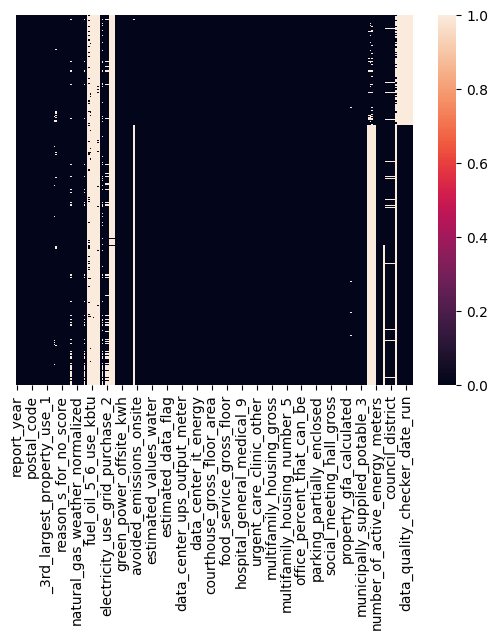

In [8]:
#alternatively, review the null values in the dataset
sns.heatmap(df.isnull(), yticklabels=False)


In [9]:
#since the dataframe contains 256 columns, storing all the field headers to a list & overwriting the df to a smaller df
extra_col = ['borough', 'report_year']
df =df[cols_to_fix + extra_col]


<Axes: >

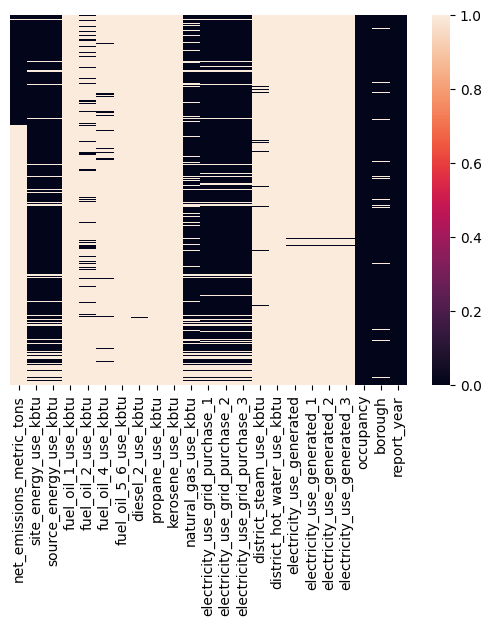

In [10]:
#alternatively, review the null values in the dataset
sns.heatmap(df.isnull(), yticklabels=False)

In [11]:
df

,net_emissions_metric_tons,site_energy_use_kbtu,source_energy_use_kbtu,fuel_oil_1_use_kbtu,fuel_oil_2_use_kbtu,fuel_oil_4_use_kbtu,fuel_oil_5_6_use_kbtu,diesel_2_use_kbtu,propane_use_kbtu,kerosene_use_kbtu,...,electricity_use_grid_purchase_3,district_steam_use_kbtu,district_hot_water_use_kbtu,electricity_use_generated,electricity_use_generated_1,electricity_use_generated_2,electricity_use_generated_3,occupancy,borough,report_year
0,29.9,520173.0,670384.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,70973.0,NaN,NaN,NaN,NaN,NaN,NaN,50,QUEENS,2022
1,216.1,3096670.2,6126701.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1642970.1,NaN,NaN,NaN,NaN,NaN,NaN,75,BRONX,2022
2,163.1,2244816.6,4799096.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1395451.0,NaN,NaN,NaN,NaN,NaN,NaN,50,QUEENS,2022
3,457.3,7314028.3,11514204.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2191128.4,NaN,NaN,NaN,NaN,NaN,NaN,100,MANHATTAN,2022
4,320.9,3838751.8,10524612.7,NaN,16560.0,NaN,NaN,NaN,NaN,NaN,...,3711191.5,NaN,NaN,NaN,NaN,NaN,NaN,80,QUEENS,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103254,NaN,5373031.6,15044488.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5373029.9,NaN,NaN,NaN,NaN,NaN,NaN,100,BROOKLYN,2024
103255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100,NaN,2024
103256,NaN,5680414.8,15905161.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5680413.6,NaN,NaN,NaN,NaN,NaN,NaN,100,BROOKLYN,2024
103257,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100,NaN,2024


In [12]:
df['report_year'].unique()

array(['2022', '2023', '2024'], dtype=object)

##Question 1: What has the trend been across the years?
Site Energy Use Intensity (EUI) measures the energy a building consumes on-site as shown in utility bills, while Source EUI tracks this energy back to the raw fuel source, including transmission and production losses. Site EUI is best for tracking utility costs, while Source EUI is used for true efficiency comparisons, such as in ENERGY STAR scores

Source: https://www.energystar.gov/buildings/benchmark/understand-metrics/source-site-difference


In [13]:
#Based on the above heatmap, all of these fields are populated. However, running another check to confirm
df[['report_year','source_energy_use_kbtu', 'site_energy_use_kbtu']].isna().sum()

,0
report_year,0
source_energy_use_kbtu,12874
site_energy_use_kbtu,12874


In [14]:
#Based on energy star's deffinition, we're comparing the source energy use to check for efficiency comparisons
df.groupby('report_year')['source_energy_use_kbtu'].sum().round(2)
#df.groupby('report_year')['site_energy_use_kbtu'].sum().round(2)

,source_energy_use_kbtu
report_year,
2022,596402590257.296143
2023,700118387904.004028
2024,611669855603.797363


<Axes: xlabel='report_year', ylabel='source_energy_use_kbtu'>

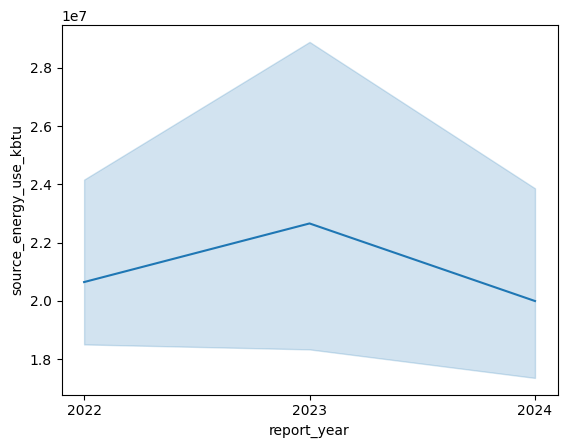

In [15]:
sns.lineplot(df, x= 'report_year', y = 'source_energy_use_kbtu')
#sns.lineplot(df, x= 'report_year', y = 'site_energy_use_kbtu')
#Based on the three year dataset, the total source energy use hasn't significantly shifted

In [16]:
#Check if there is a significant shift of energy use across the three years
#Also comparing the percent shift between years, we're also not seeing a significant shift in energy use
df_energy_use = df.groupby(['report_year'])['source_energy_use_kbtu'].sum()
df_energy_use = df_energy_use.dropna()
df_energy_use['energy_consumption_chng'] =df_energy_use.pct_change()
df_energy_use['energy_consumption_chng']

/tmp/ipykernel_1791/870157165.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_energy_use['energy_consumption_chng'] =df_energy_use.pct_change()


,source_energy_use_kbtu
report_year,
2022,NaN
2023,0.173902
2024,-0.126334


In [17]:
#also checked the average per year
df.groupby('report_year')['source_energy_use_kbtu'].mean().round(2)
#df.groupby('report_year')['site_energy_use_kbtu'].mean().round(2)


,source_energy_use_kbtu
report_year,
2022,20643911.050789
2023,22657553.006602
2024,19992477.712169


<Axes: xlabel='report_year'>

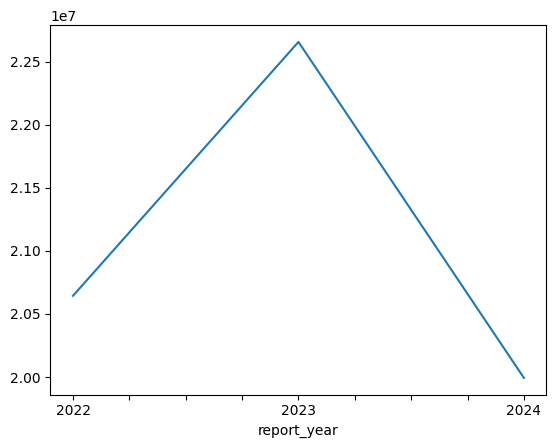

In [18]:
#graph the average
df.groupby('report_year')['source_energy_use_kbtu'].mean().round(2).plot(kind = 'line')

##Question 2: What borough consumes the most energy?

In [19]:
#Check the total emissions across years. However, only 2022 data is provided
df_emissions = df.groupby(['report_year','borough'])['net_emissions_metric_tons'].sum()
df_emissions

report_year  borough  
2022         BRONX         3163518.5
             BROOKLYN      3844314.2
             MANHATTAN    10261836.4
             QUEENS        5104019.1
             STATEN IS      512659.4
2023         BRONX                 0
             BROOKLYN              0
             MANHATTAN             0
             QUEENS                0
             STATEN IS             0
2024         BRONX                 0
             BROOKLYN              0
             MANHATTAN             0
             QUEENS                0
             STATEN IS             0
Name: net_emissions_metric_tons, dtype: object

In [20]:
#Since emissions is only available for 2022, filter dataframe to show 2022 records
df_emissions = df[df['report_year'] == "2022"]
#Also check if there are any na values prior to graphing this out
df_emissions['net_emissions_metric_tons'].isna().sum()

np.int64(134)

Text(0.5, 1.0, 'Total Emissions in 2022')

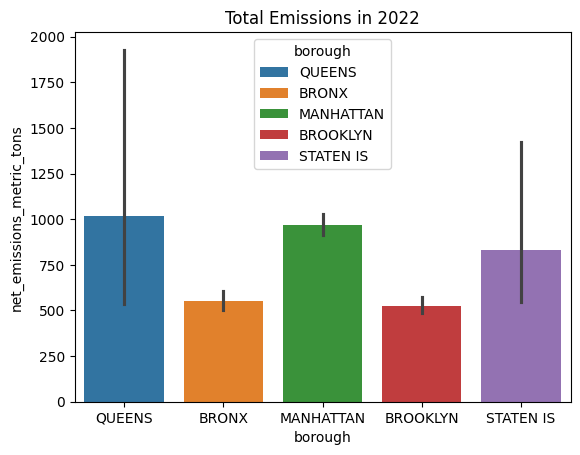

In [21]:
# Graph out the total emissions in 2022
ax = sns.barplot(df_emissions,x='borough', y= 'net_emissions_metric_tons', hue = 'borough')
ax.set_title('Total Emissions in 2022')

#Among the borougs, Queens has the most emissions in 2022.

In [22]:
#Since net_emissions_metric_tons contains too many null values, dropping the column altogether
df = df.drop(columns=['net_emissions_metric_tons'])

<Axes: >

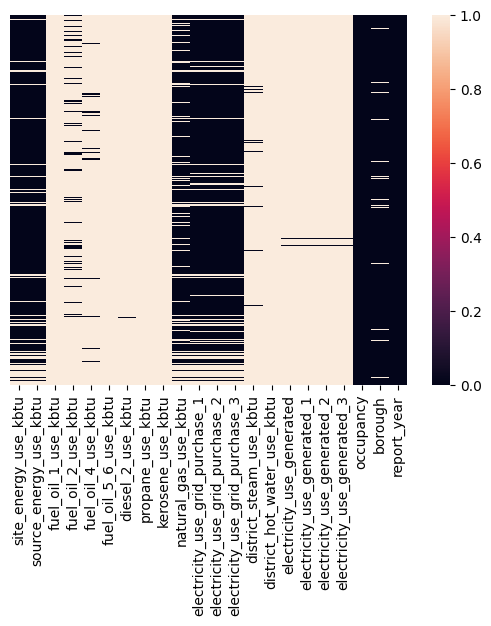

In [23]:
#after dropping the column, check how many null values are left
sns.heatmap(df.isnull(), yticklabels=False)

##Question 3: What are the current energy sources and the adoption per borough?

In [24]:
#For the next analysis, we want to check all the energy sources and compare them against each other
#setting the null values to zero
df = df.fillna(0)

/tmp/ipykernel_1791/2961091248.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(0)


<Axes: >

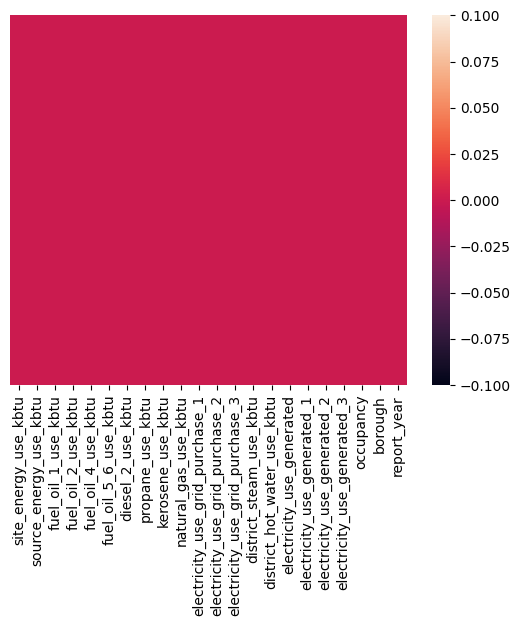

In [25]:
#confirm that there are no null values for this analysis
sns.heatmap(df.isnull(), yticklabels=False)

##Categorize the energy sources and sum up all the values to see the percentages


In [26]:
src_fossil =['natural_gas_weather_normalized','natural_gas_weather_normalized_1',
  'fuel_oil_1_use_kbtu','fuel_oil_2_use_kbtu','fuel_oil_4_use_kbtu','fuel_oil_5_6_use_kbtu',
  'diesel_2_use_kbtu'  ,'propane_use_kbtu','kerosene_use_kbtu','natural_gas_use_kbtu']
src_electric= ['electricity_use_grid_purchase_1','electricity_use_grid_purchase_2','electricity_use_grid_purchase_3']
src_other= ['district_steam_use_kbtu','district_hot_water_use_kbtu']
src_renewables= ['electricity_use_generated','electricity_use_generated_1','electricity_use_generated_2','electricity_use_generated_3']
src_all= ['src_fossil','src_electric','src_other','src_renewables']

In [27]:
#create a function or class that shows the total emmissions per source and then maybe get the percentage of that against the
def energy_sum(df:pd.DataFrame, energy_src:list):
  valid_cols = [c for c in energy_src if c in df.columns]
  return df[valid_cols].sum(axis=1)



In [28]:
df['src_fossil'] = energy_sum(df, src_fossil)
df['src_electric'] = energy_sum(df, src_electric)
df['src_other'] = energy_sum(df, src_other)
df['src_renewables'] = energy_sum(df, src_renewables)
df['src_all']=energy_sum(df,src_all)

In [29]:
df['src_all']

,src_all
0,561775.0
1,4059724.1
2,3062783.0
3,8598394.2
4,6014127.5
...,...
103254,8522520.4
103255,0.0
103256,9010081.9
103257,0.0


<Axes: xlabel='report_year', ylabel='consumption'>

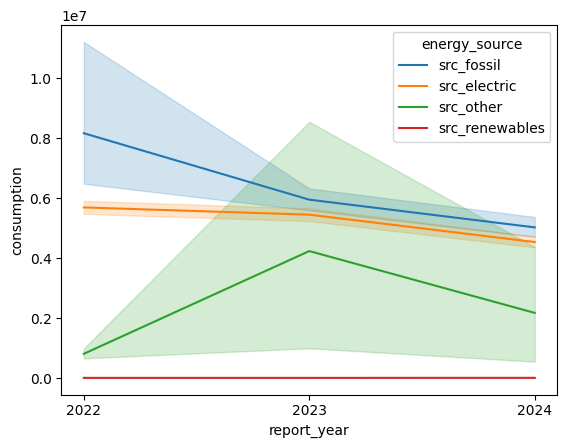

In [34]:
#After summing up the total energy use for all energy sources, check the overall breakdwon against the smaller buckets created
df_melted = df.melt(id_vars=['report_year'],
                    value_vars=['src_fossil', 'src_electric', 'src_other', 'src_renewables'],
                    var_name='energy_source', value_name='consumption')

sns.lineplot(data=df_melted, x='report_year', y='consumption', hue='energy_source')
#Based on the graph, although fossil fuel consumption has decreased, this remains to be the highest energy source in NYC
#Notably, the renewable energy sources hasn't significantly changed within the three years

array([<Axes: ylabel='src_fossil'>, <Axes: ylabel='src_electric'>,
       <Axes: ylabel='src_other'>, <Axes: ylabel='src_renewables'>],
      dtype=object)

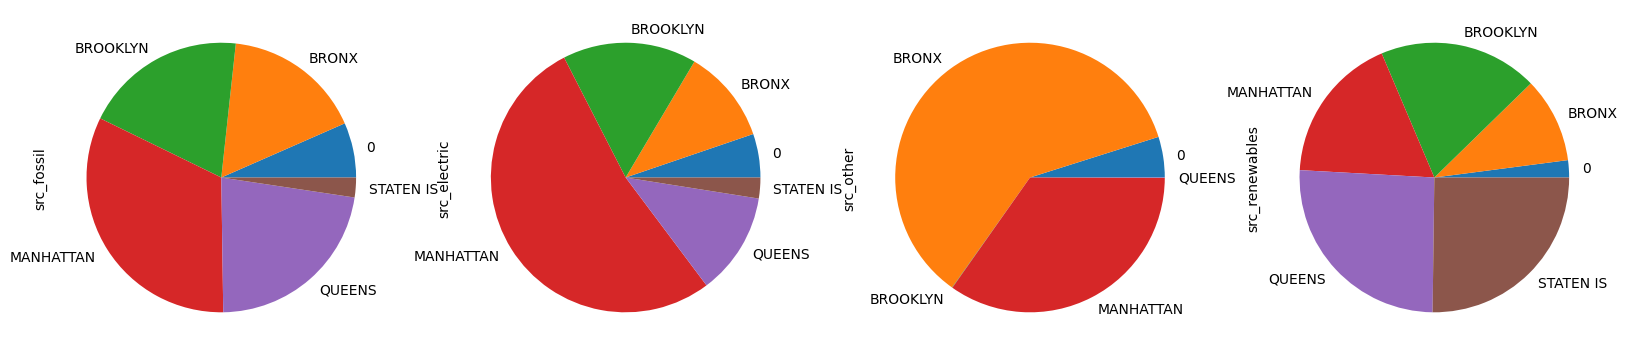

In [31]:
#Among all the energy sources, also review the total energy consumption across boroughs
summary = df.groupby('borough')[['src_fossil', 'src_electric', 'src_other', 'src_renewables']].sum()
summary.plot(kind='pie', subplots=True, figsize=(20, 10),  legend=False)

#Notably, The Bronx is the Borough that utilizes steam/ water as energy source. This could be due to early industrial growth was established in Bronx
#Also, Manhattan primarily sources energy through electric purchase through a grid. This means that a utility like ConEd.
#source: https://www.nycgovparks.org/parks/saw-mill-playground/history#:~:text=Sawmills%20flourished%20along%20the%20Bronx's,colonial%2Dera%20sawmills%20nearly%20obsolete.

In [32]:
df.shape

(103259, 27)